# The Real Story: Skills-Related Underemployment

## The Question

Notebooks 01 and 02 tested whether graduates can *get* a job. This notebook asks a different question entirely: of the graduates who *do* have a job, how many are in a job that doesn't actually need their degree, and is that getting better or worse over time?

## The Answer

This is where the real story is. As of mid-2025, **74.3% of employed 15–24 year-olds with tertiary education were in a semi-skilled or low-skilled job**, more than double the 35.5% overall rate across all ages, and consistently 1.8–2.3x the overall rate in every quarter since 2017. The youth series is genuinely volatile quarter to quarter (it swung from 58% to 80% within a single year, 2022–2023) rather than climbing in a clean line, but the overall rate has moved far less over the same period, climbing gradually from ~30% to ~36% and essentially flat since 2021. Read plainly: youth underemployment isn't trending as cleanly upward as a single before/after comparison would suggest, but it has sat roughly twice the overall rate for eight straight years, which is the more defensible finding here. Malaysia's graduate story isn't primarily about unemployment. It's about underemployment, concentrated specifically among the youngest graduates, and structurally elevated rather than improving.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
sru = pd.read_csv('../data/processed/skills_underemployment_by_age.csv')
sru['date'] = pd.to_datetime(sru['date'])
sru.pivot(index='date', columns='age', values='skills_underemployment_rate_pct').tail()

age,15-24,25-34,35-44,45+,overall
date,,,,,
2024-07-01,65.1,41.3,28.1,23.0,36.0
2024-10-01,67.9,38.9,27.1,29.9,35.8
2025-01-01,70.7,40.3,28.0,23.1,35.7
2025-04-01,74.4,40.9,28.3,18.7,35.6
2025-07-01,74.3,41.0,24.9,22.1,35.5


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Skills-related underemployment rate: youngest workers vs. everyone

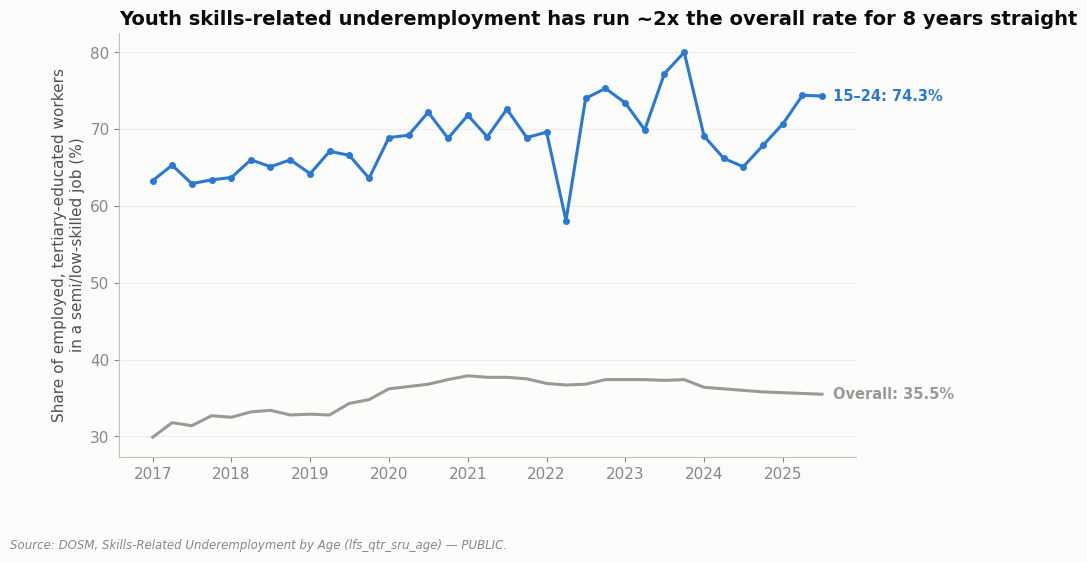

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
young = sru[sru['age'] == '15-24']
overall = sru[sru['age'] == 'overall']
ax.plot(young['date'], young['skills_underemployment_rate_pct'], color=ACCENT_1, linewidth=2.2, marker='o', markersize=4)
ax.plot(overall['date'], overall['skills_underemployment_rate_pct'], color=GRAY, linewidth=2.2)
end_label(ax, young['date'].iloc[-1], young['skills_underemployment_rate_pct'].iloc[-1],
          f"15\u201324: {young['skills_underemployment_rate_pct'].iloc[-1]:.1f}%", ACCENT_1, weight='bold')
end_label(ax, overall['date'].iloc[-1], overall['skills_underemployment_rate_pct'].iloc[-1],
          f"Overall: {overall['skills_underemployment_rate_pct'].iloc[-1]:.1f}%", GRAY)
ax.set_title('Youth skills-related underemployment has run ~2x the overall rate for 8 years straight', loc='left')
ax.set_ylabel('Share of employed, tertiary-educated workers\nin a semi/low-skilled job (%)')
add_source(ax.figure, 'Source: DOSM, Skills-Related Underemployment by Age (lfs_qtr_sru_age) \u2014 PUBLIC.')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's finding; kept separate from the PUBLIC LFS figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

Independent research converges on two structural drivers, not a temporary blip:

1. **Graduate supply has outpaced the creation of graduate-level jobs, concentrated in specific fields.** Analysis of Malaysia's labour market finds the oversupply concentrated in arts, social sciences, and general business programmes, while technology and specialised industrial fields simultaneously report talent *shortages*, a genuine field-of-study mismatch, not a uniform "too many graduates" problem.
2. **This shows up as a documented "sheepskin effect":** as more people hold degrees, a degree alone signals less to employers, and one Malaysian analysis found degree-holder underemployment spiked to 44.2% in 2022, with roughly 70% of employed graduates in semi- or low-skilled roles that same year; figures that track closely with the DOSM series charted above.

Read together with Notebook 02, this suggests the youth-underemployment spike isn't purely a transition-friction story either, part of it is a genuine, persistent structural mismatch between what universities are producing and what employers in those specific fields are hiring for.

**Sources:** [Human Resources Online, "Malaysia faces graduate oversupply, skilled job shortage..."](https://www.humanresourcesonline.net/malaysia-faces-graduate-oversupply-skilled-job-shortage-and-a-growing-gaji-cukup-makan-reality); [The Star, "Skills mismatch or graduate oversupply?"](https://www.thestar.com.my/news/education/2023/12/17/skills-mismatch-or-graduate-oversupply).

## Strategic Recommendation

- **A prospective student choosing a field of study should weight this more heavily than the headline unemployment rate.** The risk isn't primarily "no job"; it's "a job beneath your degree," and that risk is concentrated in specific, identifiable fields (arts, social sciences, general business) rather than spread evenly.
- **A business building an early-career pipeline in a shortage field (tech, specialised industrial roles) is competing for a genuinely scarce pool**, the oversupply story does not apply uniformly across all graduates.

## Confidence & Caveats

- **"Semi-skilled or low-skilled" is DOSM's own occupational classification, not a judgment this project is making about any individual's job.** A graduate working in a role classified this way may still consider it a good job; the metric captures a mismatch with formal qualification level, not job satisfaction or income.
- **The field-of-study figures (70% low-skilled, 44.2% underemployment in 2022) are DERIVED from secondary reporting**, not a primary MOHE Graduate Tracer Study dataset this session accessed directly. See `DATA_DICTIONARY.md`.